<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/03c_visualizations_sean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install contextily

##Importing

In [20]:

import pandas as pd
import geopandas as gpd
import numpy as np
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import contextily as cx

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:

!ls /content/drive
!ls /content/drive/Shareddrives

MyDrive  Shareddrives


##Reading in file

In [22]:
gdf = pd.read_csv("/content/drive/MyDrive/C255_final_project/cleaned/rbl_rde_cleaned.csv")

##Reading in Census Tracts

In [23]:
url = "https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_06_place.zip"

places = gpd.read_file(url)

# Filtered to SF
sf_poly = places[
    (places["NAME"] == "San Francisco") &
    (places["STATEFP"] == "06")   # 06 = California
]

# eproject to same as our gdf
sf_poly = sf_poly.to_crs(epsg=4326)

In [24]:
import plotly.express as px

##Reading in Census Tracts

In [25]:
tracts_gdf = gpd.read_file(
    "/content/drive/MyDrive/C255_final_project/cb_2020_06_tract_500k"
)
# simplifying
tracts_gdf = tracts_gdf[["NAME", "NAMELSAD", "STATE_NAME","GEOID", "geometry"]]
#troubleshooting
tracts_gdf = tracts_gdf.drop(columns=["index_right", ], errors="ignore")
gdf = gdf.drop(columns=["index_right"], errors="ignore")

##Joining census tracts

In [26]:
gdf = gdf.set_geometry(
    gpd.points_from_xy(gdf.lon, gdf.lat)
)

gdf = gdf.set_crs(epsg=4326)
tracts_gdf = tracts_gdf.to_crs(epsg=4326)

# joining within
business_tracts_gdf = gpd.sjoin(gdf, tracts_gdf, how="left", predicate="within")

##Limiting to time period 2016-2025

In [27]:
business_tracts_gdf = business_tracts_gdf[(business_tracts_gdf["year"] >= 2016) & (business_tracts_gdf["year"] <= 2025)]

##Limiting columns

In [28]:
business_tracts_gdf.columns.tolist()

cols_to_keep = [
    "dba_name",
    "uniqueid",
    "naics_code",
    "year",
    "status",
    "location_start_date",
    "location_end_date",
    "GEOID",
    "geometry",
    "lon", "lat"
]

business_tracts_gdf_clipped = business_tracts_gdf[cols_to_keep]

In [29]:
# I'm counting the number of businesses per tract per year, separated by closing and openings status
tract_year = (
    business_tracts_gdf_clipped
    .groupby(["GEOID", "year", "status"])
    .size()
    .reset_index(name="count")
    .pivot(index=["GEOID", "year"], columns="status", values="count")
    .fillna(0)
    .reset_index()
)


status,GEOID,year,closed,opened
0,06001403401,2023,1.0,1.0
1,06001410000,2018,0.0,1.0
2,06001421800,2018,2.0,3.0
3,06001425104,2021,0.0,1.0
4,06001425104,2022,1.0,0.0
...,...,...,...,...
2398,06081984300,2020,0.0,1.0
2399,06081984300,2022,0.0,1.0
2400,06081984300,2023,0.0,4.0
2401,06085512045,2017,0.0,1.0


In [30]:
tracts_plot = tracts_gdf[["GEOID", "geometry"]].merge(
    tract_year,
    on="GEOID",
    how="left"
).fillna(0)

#clipping to sf only
tracts_plot.info()
tracts_plot = gpd.clip(tracts_plot, sf_poly)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11259 entries, 0 to 11258
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   GEOID     11259 non-null  object  
 1   geometry  11259 non-null  geometry
 2   year      11259 non-null  float64 
 3   closed    11259 non-null  float64 
 4   opened    11259 non-null  float64 
dtypes: float64(3), geometry(1), object(1)
memory usage: 439.9+ KB


In [70]:
#formatting and sorting

tracts_plot["year"] = tracts_plot["year"].astype(int)
tracts_plot = tracts_plot.sort_values(["GEOID", "year"])
tracts_plot

,GEOID,geometry,year,closed,opened
7487,06001428700,"MULTIPOLYGON (((-122.32871 37.78246, -122.3286...",0,0.0,0.0
6000,06041124200,"MULTIPOLYGON (((-122.42037 37.86334, -122.4195...",0,0.0,0.0
3053,06041131100,"MULTIPOLYGON (((-122.47807 37.83272, -122.4781...",0,0.0,0.0
10831,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2016,8.0,28.0
10832,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2017,17.0,29.0
...,...,...,...,...,...
10029,06081600300,"MULTIPOLYGON (((-122.44208 37.70823, -122.4413...",0,0.0,0.0
5144,06081600401,"MULTIPOLYGON (((-122.44975 37.70821, -122.4486...",0,0.0,0.0
7511,06081600402,"MULTIPOLYGON (((-122.45027 37.7082, -122.451 3...",0,0.0,0.0
3096,06081600701,"MULTIPOLYGON (((-122.46894 37.70823, -122.467 ...",0,0.0,0.0


In [71]:
## net change from prior year
tracts_plot_cleaned = tracts_plot[tracts_plot['year'] != 0]
tracts_plot_cleaned['net_change_prior_year'] = tracts_plot_cleaned['opened'] - tracts_plot_cleaned['closed']
tracts_plot_cleaned

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,GEOID,geometry,year,closed,opened,net_change_prior_year
10831,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2016,8.0,28.0,20.0
10832,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2017,17.0,29.0,12.0
10833,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2018,13.0,37.0,24.0
10834,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2019,24.0,33.0,9.0
10835,06075010101,"POLYGON ((-122.41586 37.80869, -122.41266 37.8...",2020,21.0,14.0,-7.0
...,...,...,...,...,...,...
7233,06075980900,"POLYGON ((-122.40459 37.74413, -122.40356 37.7...",2021,40.0,48.0,8.0
7234,06075980900,"POLYGON ((-122.40459 37.74413, -122.40356 37.7...",2022,38.0,27.0,-11.0
7235,06075980900,"POLYGON ((-122.40459 37.74413, -122.40356 37.7...",2023,38.0,42.0,4.0
7236,06075980900,"POLYGON ((-122.40459 37.74413, -122.40356 37.7...",2024,42.0,30.0,-12.0


In [69]:
#net change 2016 to 2025
net_change_2016_2025 = (tracts_plot_cleaned.groupby(['GEOID', 'geometry'])['opened'].sum().rename('count') - tracts_plot_cleaned.groupby('GEOID')['closed'].sum().rename('count')).reset_index()
net_change_2016_2025 = gpd.GeoDataFrame(net_change_2016_2025, geometry='geometry', crs='EPSG:4326')
net_change_2016_2025.sort_values(by='count', ascending=False)

,GEOID,geometry,count
20,06075011700,"POLYGON ((-122.40715 37.79037, -122.40734 37.7...",286.0
92,06075018000,"POLYGON ((-122.40852 37.77376, -122.40407 37.7...",159.0
219,06075060701,"POLYGON ((-122.39738 37.771, -122.39464 37.773...",157.0
240,06075980900,"POLYGON ((-122.40459 37.74413, -122.40356 37.7...",131.0
71,06075016200,"POLYGON ((-122.425 37.77854, -122.42335 37.778...",124.0
...,...,...,...
81,06075017000,"POLYGON ((-122.44354 37.76532, -122.44258 37.7...",3.0
238,06075980501,"POLYGON ((-122.42639 37.71856, -122.42548 37.7...",2.0
236,06075980200,"POLYGON ((-122.50748 37.78218, -122.50984 37.7...",1.0
38,06075012504,"POLYGON ((-122.41198 37.78095, -122.41255 37.7...",-1.0


In [34]:
epc_tracts = gpd.read_file("/content/drive/MyDrive/C255_final_project/epc_tracts.geojson")

In [35]:
epc_tracts = gpd.clip(epc_tracts, sf_poly)
epc_tracts = epc_tracts.to_crs('EPSG:4326')

In [67]:
import plotly.graph_objects as go

fig = px.choropleth_mapbox(
    net_change_2016_2025,
    geojson=net_change_2016_2025.set_index("GEOID").__geo_interface__,
    locations="GEOID",
    color="count",
    hover_name="GEOID",
    center={"lat": 37.7749, "lon": -122.4194},
    zoom=10,
    mapbox_style="carto-positron",
    color_continuous_scale="Reds",
    height=500,
    width=700

)

# # Add EPC overlay
# fig.add_trace(go.Choroplethmapbox(
#     geojson=epc_tracts.set_index("GEOID").__geo_interface__,
#     locations=epc_tracts["GEOID"],
#     z=[1]*len(epc_tracts),

#     showscale=False,
#     marker_opacity=0.3,
#     marker_line_width=1,
#     marker_line_color="blue",
#     name="EPC Tracts",

# ))

fig.update_layout(
    title="Net change in retail, dining and entertainment by census tract (2016–2025) <br>with EPC Communities"
)

fig.show()

In [102]:
#going back to original gdf to avoid carrying tract columns

gdf_open_close = gdf[['status', 'year', 'uniqueid', 'naics_code_description']]
gdf_open_close = gdf_open_close[gdf_open_close.year < 2026]
#gdf by year

gdf_counts = (
    gdf_open_close
    .groupby(['year', 'status'])['uniqueid']
    .count()
    .reset_index(name='count')
)


<Axes: xlabel='year', ylabel='count'>

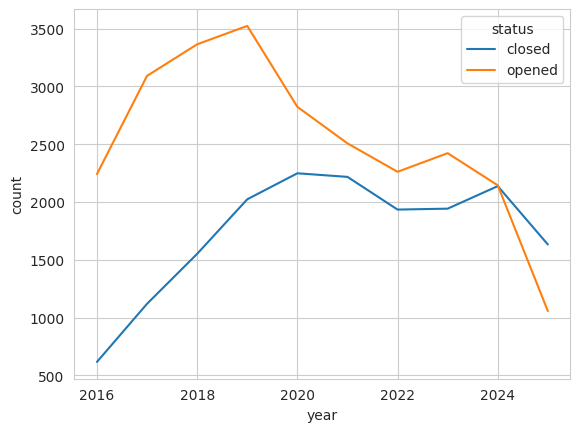

In [103]:
#using gdf_counts to make line graph per year - Sean

import seaborn as sns

sns.set_style(style='whitegrid')
sns.lineplot(gdf_counts, x='year', y='count', hue='status')

In [111]:
gdf_by_year = (
    gdf_open_close
    .groupby(["year", "status"])
    .size()
    .reset_index(name="count")
    .pivot(index="year", columns="status", values="count")
    .fillna(0)
    .reset_index()
)
gdf_by_year['net_change'] = gdf_by_year['opened'] - gdf_by_year['closed']
gdf_by_year

status,year,closed,opened,net_change
0,2016,616,2241,1625
1,2017,1119,3091,1972
2,2018,1551,3364,1813
3,2019,2023,3523,1500
4,2020,2248,2823,575
5,2021,2217,2507,290
6,2022,1934,2261,327
7,2023,1942,2422,480
8,2024,2137,2144,7
9,2025,1632,1056,-576


<Axes: xlabel='year', ylabel='net_change'>

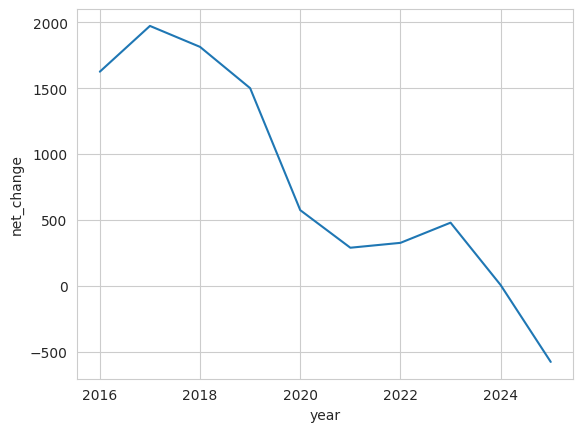

In [112]:
sns.lineplot(gdf_by_year, x='year', y='net_change')

<Axes: xlabel='year', ylabel='cumulative_change'>

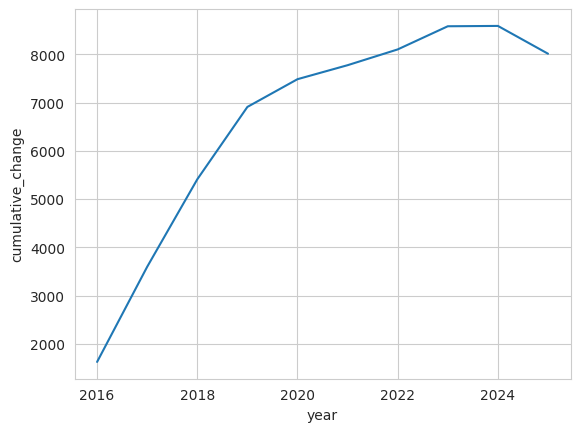

In [113]:
##cumulative sum
gdf_by_year["cumulative_change"] = gdf_by_year["net_change"].cumsum()
#plotting
sns.lineplot(gdf_by_year, x='year', y='cumulative_change')

<Axes: xlabel='year', ylabel='opened'>

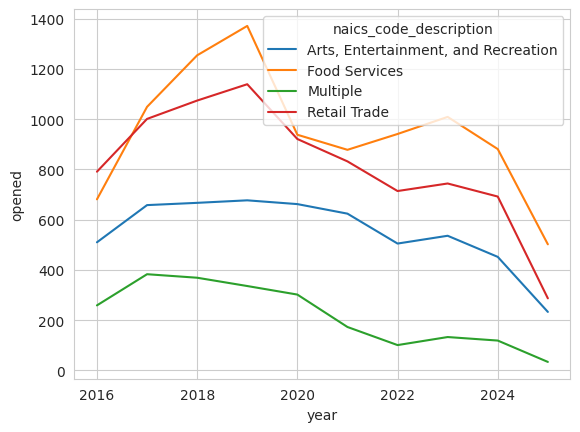

In [122]:
gdf_by_year_by_code = (
    gdf_open_close
    .groupby(["year", "naics_code_description", "status"])
    .size()
    .reset_index(name="count")
    .pivot(index=["year", "naics_code_description"], columns="status", values="count")
    .fillna(0)
    .reset_index()
)
gdf_by_year_by_code['net_change'] = gdf_by_year_by_code['opened'] - gdf_by_year_by_code['closed']

sns.lineplot(gdf_by_year_by_code, x='year', y='opened', hue='naics_code_description')


<Axes: xlabel='year', ylabel='closed'>

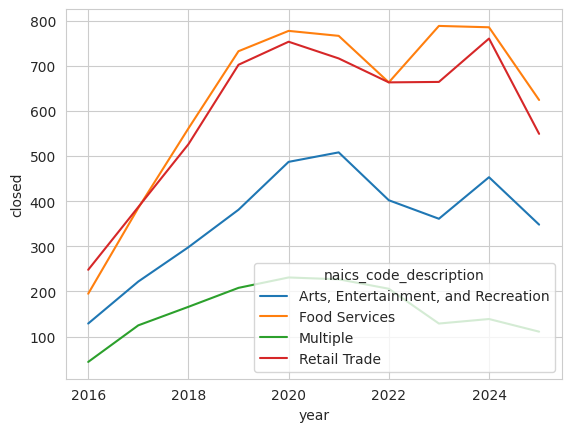

In [121]:
sns.lineplot(gdf_by_year_by_code, x='year', y='closed', hue='naics_code_description')

<Axes: xlabel='year', ylabel='net_change'>

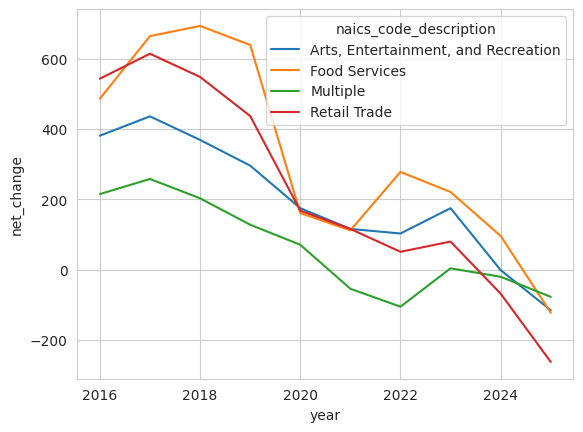

In [123]:
sns.lineplot(gdf_by_year_by_code, x='year', y='net_change', hue='naics_code_description')

##Do we need to zoom out further past 2016?